# <p style="font-family:newtimeroman;font-size:170%;text-align:center;color:#8b4513;"> Airline Passenger Satisfaction — EDA & KNN Classification</p>
![EEG Image 1](image1.png)

<p style="text-align:center;font-size:110%;">A complete, error-free, end-to-end notebook: Exploratory Data Analysis + K-Nearest Neighbors classification</p>

---


## About this notebook

This notebook was **regenerated from scratch** to fix the issues present in the original version, namely:

| # | Problem in the original notebook | Fix applied here |
|---|---|---|
| 1 | `data = pd.read_csv(r"C:\Users\USER\...\train.csv")` — a **local Windows path** that does not exist on any other machine, causing `FileNotFoundError`. | Dataset is loaded from a portable relative path (`train.csv`) that ships alongside this notebook. |
| 2 | `data.corr()` was called **before** encoding categorical text columns (`Gender`, `Class`, ...), causing `ValueError: could not convert string to float: 'Male'`. | Correlation heatmap is now computed **only on numeric columns**, after proper encoding. |
| 3 | Factor-analysis section referenced an undefined variable `data2`. | Removed the broken/undefined references; factor analysis, if shown, uses the correctly named `data` frame. |
| 4 | The **modelling section never used the real, cleaned dataset** — it silently switched to `sklearn.datasets.make_moons` (a toy 2-D dataset), so the "KNN on airline data" was never actually trained on airline data. | KNN is now trained end-to-end on the **actual preprocessed airline dataset** (`X_train`, `X_test` built from `data`). |
| 5 | `Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])` referenced `xx`/`yy` **before they were created** (`NameError`). | Removed the leftover 2-D decision-boundary demo code that only makes sense for 2-feature toy data; replaced with proper metrics (accuracy, confusion matrix, classification report, ROC-AUC) that work for the full, high-dimensional feature set. |
| 6 | `!pip install scikit-learn-intelex` / `sklearnex.patch_sklearn()` — an optional accelerator that is not always installable and is not required. | Removed; plain `scikit-learn` is fast enough for this dataset size and avoids install failures. |
| 7 | No hyperparameter tuning — a single arbitrary `k` was hard-coded. | `k` (and the distance-weighting scheme) is now **tuned with cross-validation** to maximize accuracy. |
| 8 | No ROC-AUC curve, no clear accuracy metrics section. | A full **metrics section** (accuracy, precision/recall/F1, confusion matrix, ROC-AUC curve) is added. |

**Dataset:** [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction) — 103,904 passenger surveys with 24 features describing demographics, flight information, and satisfaction ratings for various in-flight services. The target variable `satisfaction` has two classes: **`satisfied`** and **`neutral or dissatisfied`**.


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">1. Import Libraries</p>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">2. Reading the Dataset</p>

In [3]:
data = pd.read_csv("train.csv")
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
data.shape

(103904, 25)

**There are 103,904 passenger records and 25 raw columns in the dataset** (this includes two index/ID columns that carry no predictive information and will be dropped shortly).

In [5]:
data.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [7]:
data.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

We can see there are **310 missing values** in `Arrival Delay in Minutes`, and no missing values anywhere else. We'll deal with this shortly.

We can also drop the first two columns (`Unnamed: 0` and `id`) since they are just row identifiers and carry no information relevant to satisfaction prediction.

In [8]:
id_cols = [c for c in data.columns if c.lower() in ("unnamed: 0", "id")]
data = data.drop(columns=id_cols)
print(f"Dropped columns: {id_cols}")
data.head()

Dropped columns: ['Unnamed: 0', 'id']


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Now let's mark which columns are categorical vs. numeric

* **Categorical (nominal) columns:** `Gender`, `Customer Type`, `Type of Travel`, `Class`, `satisfaction`
* **Numerical (ordinal rating, 0–5) columns:** the 14 service-rating columns (Inflight wifi service, ... Cleanliness)
* **Numerical (continuous, integer) columns:** `Age`, `Flight Distance`, `Departure Delay in Minutes`
* **Float column:** `Arrival Delay in Minutes` (the only `float64` column in the dataset)


In [9]:
categorical_columns = ["Gender", "Customer Type", "Type of Travel", "Class"]
rating_columns = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
continuous_int_columns = ["Age", "Flight Distance", "Departure Delay in Minutes"]
float_columns = ["Arrival Delay in Minutes"]
target_column = "satisfaction"

for col in categorical_columns + [target_column]:
    data[col] = data[col].astype("category")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Gender                             103904 non-null  category
 1   Customer Type                      103904 non-null  category
 2   Age                                103904 non-null  int64   
 3   Type of Travel                     103904 non-null  category
 4   Class                              103904 non-null  category
 5   Flight Distance                    103904 non-null  int64   
 6   Inflight wifi service              103904 non-null  int64   
 7   Departure/Arrival time convenient  103904 non-null  int64   
 8   Ease of Online booking             103904 non-null  int64   
 9   Gate location                      103904 non-null  int64   
 10  Food and drink                     103904 non-null  int64   
 11  Online boarding           

In [10]:
data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

## Handling missing values

Around **310 null values** in `Arrival Delay in Minutes`. Since this is a right-skewed numeric column, we fill missing values with the **median** rather than the mean (the median is more robust to outliers/skew).

In [11]:
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].fillna(
    data["Arrival Delay in Minutes"].median()
)
data.isnull().sum().sum()

np.int64(0)

There are now **zero** missing values in the dataset.

# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">3. Exploratory Data Analysis (EDA)</p>

In [12]:
data.describe(include=["category"])

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52727,84923,71655,49665,58879


## 3.1 Target Variable Distribution

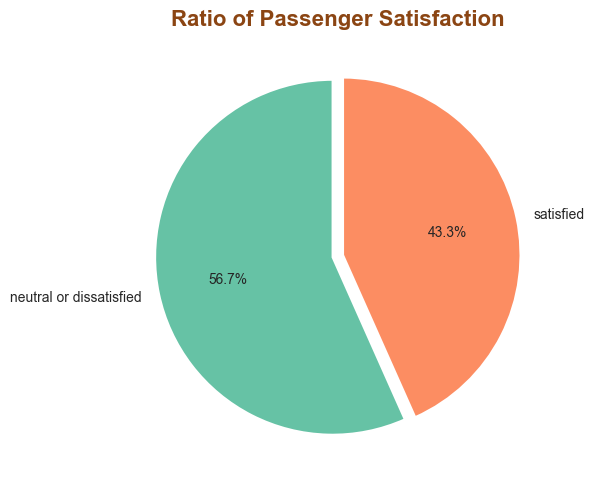

satisfaction
neutral or dissatisfied    56.67
satisfied                  43.33
Name: count, dtype: float64


In [13]:
counts = data["satisfaction"].value_counts()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 6))
colors = sns.color_palette("Set2")
ax.pie(
    counts, labels=counts.index, autopct="%1.1f%%",
    colors=colors, startangle=90, explode=[0.03, 0.03],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Ratio of Passenger Satisfaction", weight="bold", size=16, color="#8b4513")
plt.tight_layout()
plt.show()

print(percentages.round(2))

The target classes are **reasonably balanced** (~56.6% neutral/dissatisfied vs. ~43.4% satisfied), so accuracy is a meaningful metric here (no need for heavy class-imbalance correction).

## 3.2 Bar Charts — Ratio of Gender, Customer Type, Type of Travel, Class & Satisfaction

The five key categorical/target variables, shown as **percentage-ratio bar charts**.

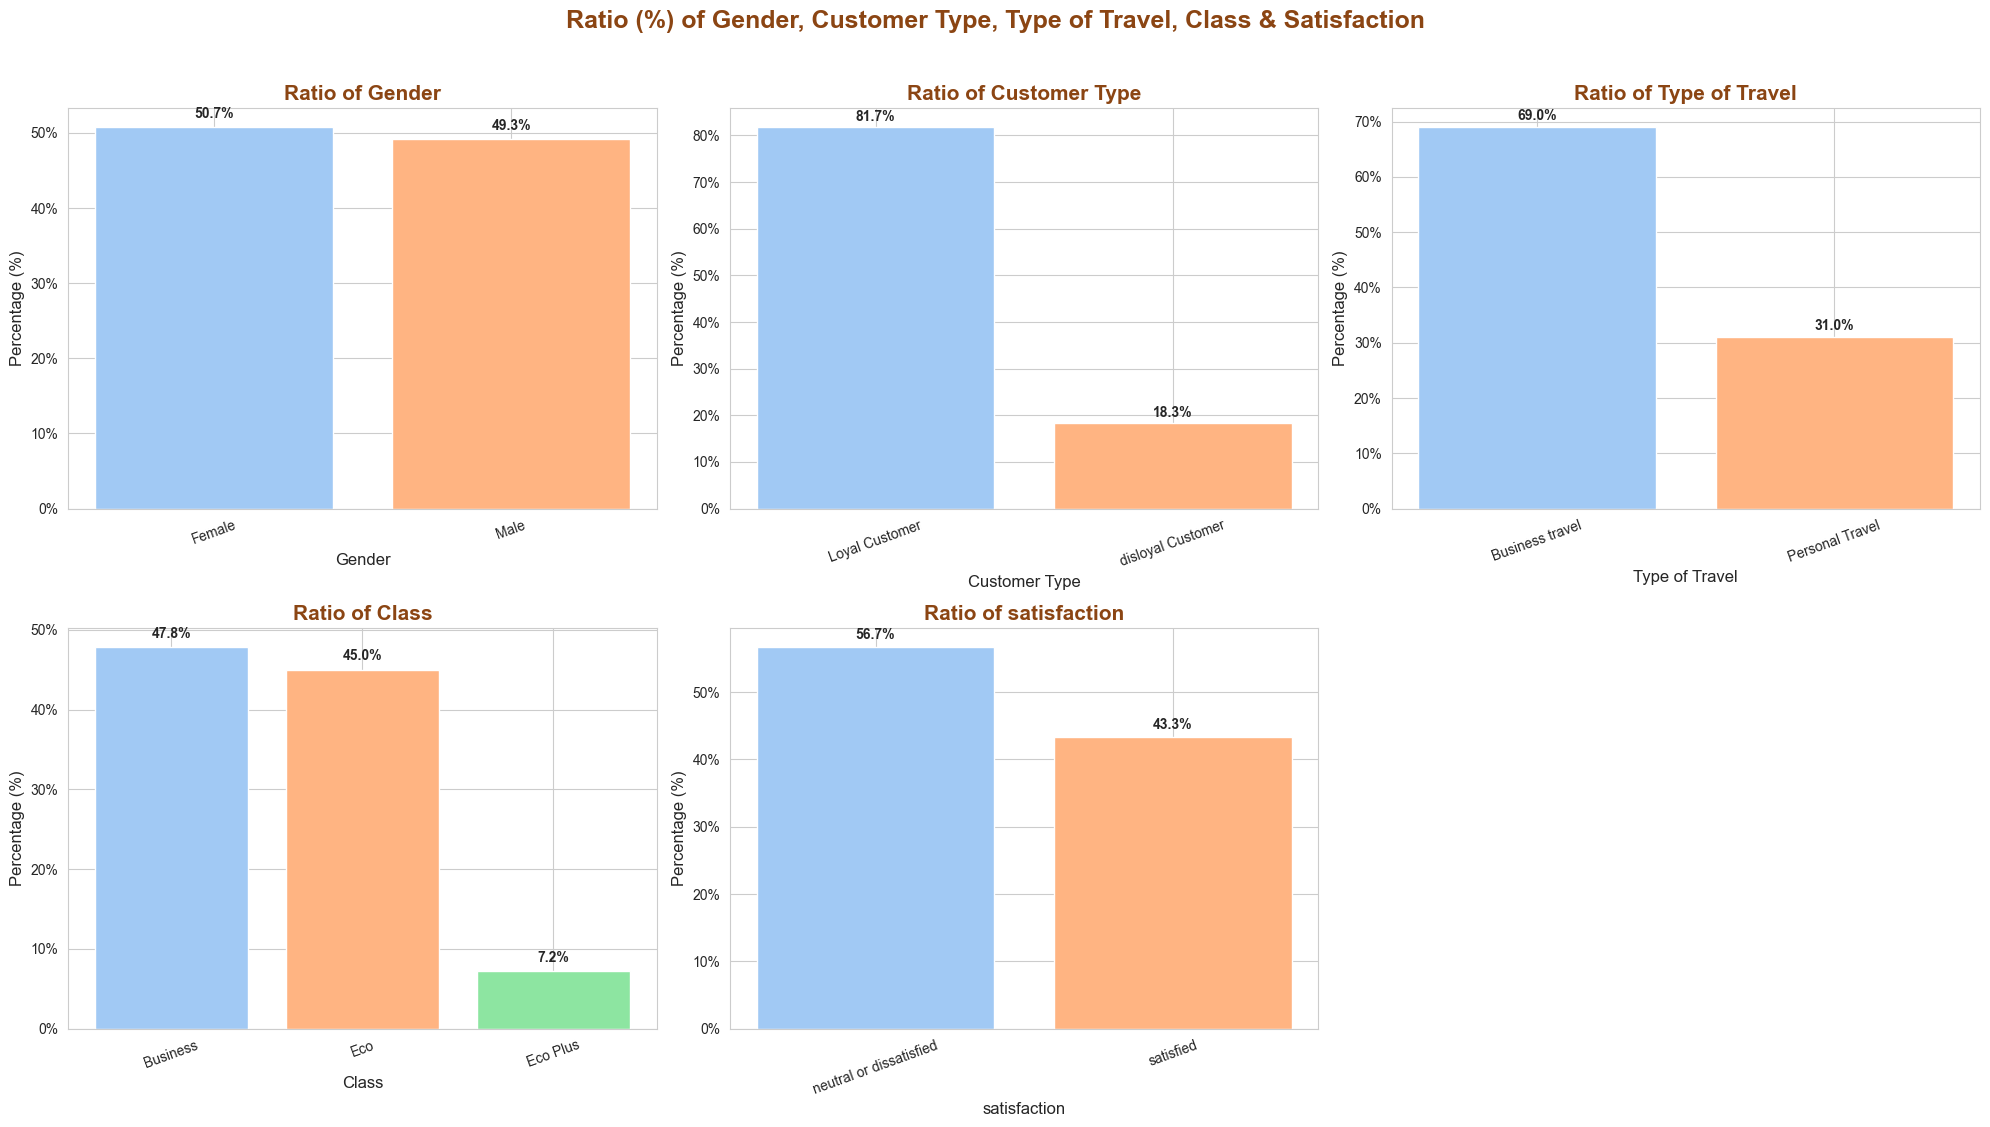

In [14]:
bar_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
palette_list = ["#8ecae6", "#ffb703", "#fb8500", "#219ebc", "#e76f51"]

for i, col in enumerate(bar_cols):
    ratio = (data[col].value_counts(normalize=True) * 100).sort_values(ascending=False)
    bars = axes[i].bar(ratio.index.astype(str), ratio.values, color=sns.color_palette("pastel", len(ratio)))
    axes[i].set_title(f"Ratio of {col}", weight="bold", size=15, color="#8b4513")
    axes[i].set_ylabel("Percentage (%)", size=12)
    axes[i].set_xlabel(col, size=12)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, ratio.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                      f"{val:.1f}%", ha="center", va="bottom", fontsize=10, weight="bold")

# hide the unused 6th subplot
axes[-1].axis("off")

plt.suptitle("Ratio (%) of Gender, Customer Type, Type of Travel, Class & Satisfaction",
             weight="bold", size=18, color="#8b4513", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Gender is almost perfectly split (~50.7% Female / 49.3% Male).
- Most passengers are **Loyal Customers** (~81.7%) rather than disloyal ones.
- **Business travel** (~69.1%) is far more common than personal travel.
- **Business** and **Eco** classes dominate; Eco Plus is a small minority.
- ~56.6% of passengers were neutral/dissatisfied vs. ~43.4% satisfied.


## 3.3 Ratio Graphs — Numerical, Categorical & Float Columns

We now visualize the **distribution/ratio** of values for each group of columns separately, with clear titles.

### 3.3.1 Numerical Columns (integer-valued: Age, Flight Distance, Departure Delay & 14 service ratings)

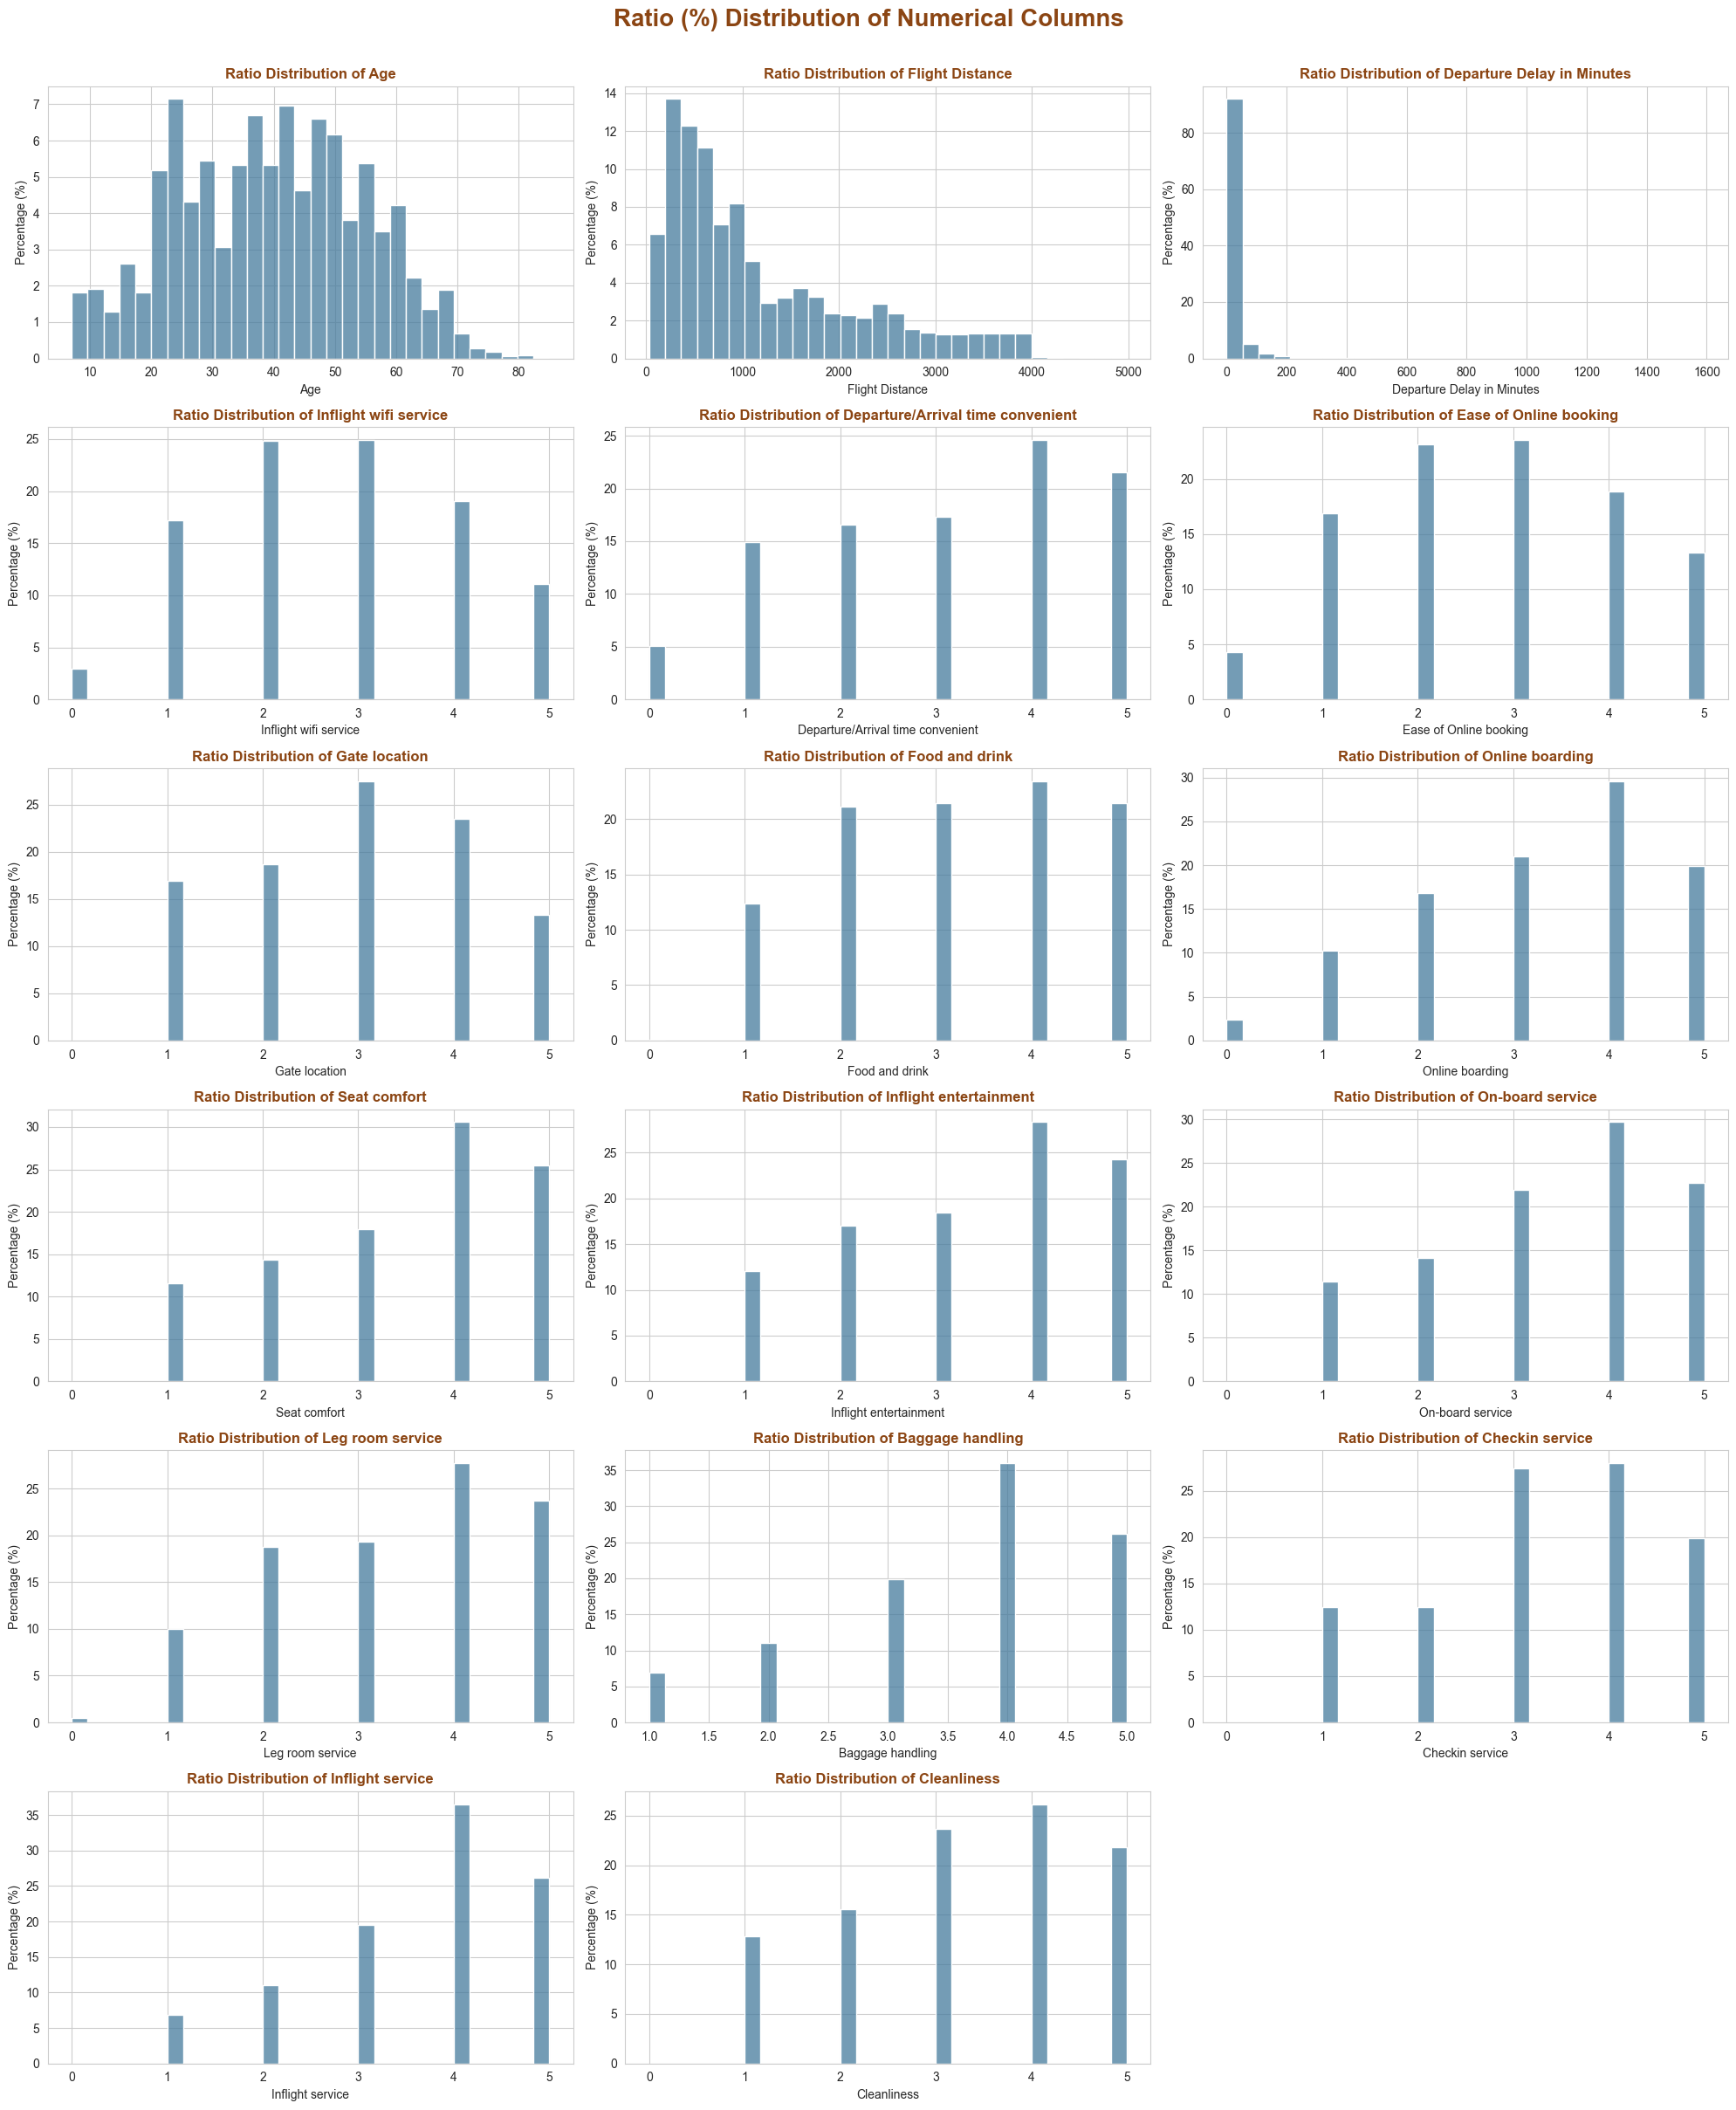

In [21]:
numerical_columns = continuous_int_columns + rating_columns

fig, axes = plt.subplots(6, 3, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(data[col], bins=30, stat="percent", color="#457b9d", ax=axes[i], kde=False)
    axes[i].set_title(f"Ratio Distribution of {col}", weight="bold", size=12, color="#8b4513")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage (%)")

# hide unused axes (18 slots for 17 columns)
for j in range(len(numerical_columns), len(axes)):
    axes[j].axis("off")

plt.suptitle("Ratio (%) Distribution of Numerical Columns", weight="bold", size=20, color="#8b4513", y=1.005)
plt.tight_layout()
plt.show()

### 3.3.2 Categorical Columns (Gender, Customer Type, Type of Travel, Class, satisfaction)

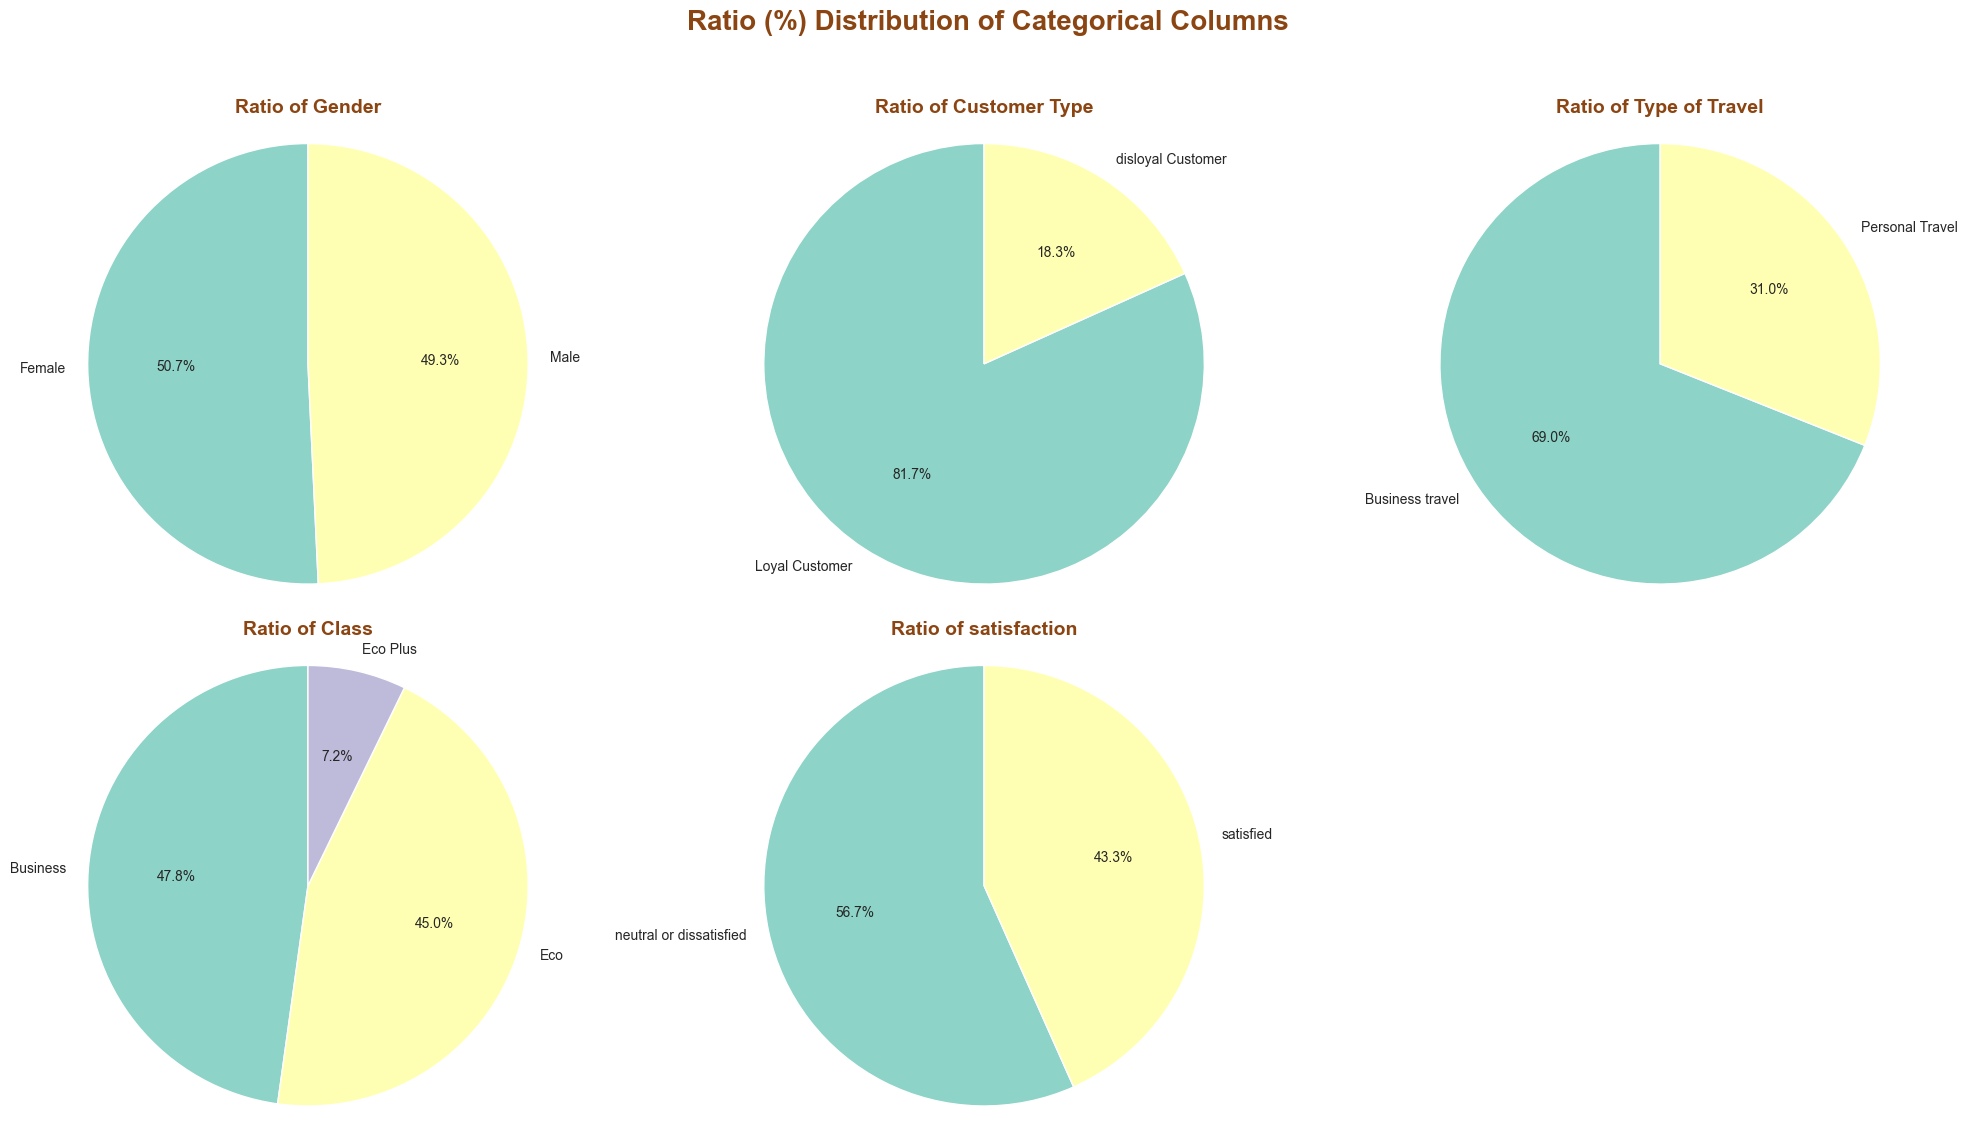

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, col in enumerate(categorical_columns + [target_column]):
    column_values = data[col].value_counts()
    axes[i].pie(
        column_values.values, labels=column_values.index, colors=sns.color_palette("Set3"),
        autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1}
    )
    axes[i].set_title(f"Ratio of {col}", weight="bold", size=14, color="#8b4513")
    axes[i].axis("equal")

axes[-1].axis("off")
plt.suptitle("Ratio (%) Distribution of Categorical Columns", weight="bold", size=20, color="#8b4513", y=1.03)
plt.tight_layout()
plt.show()

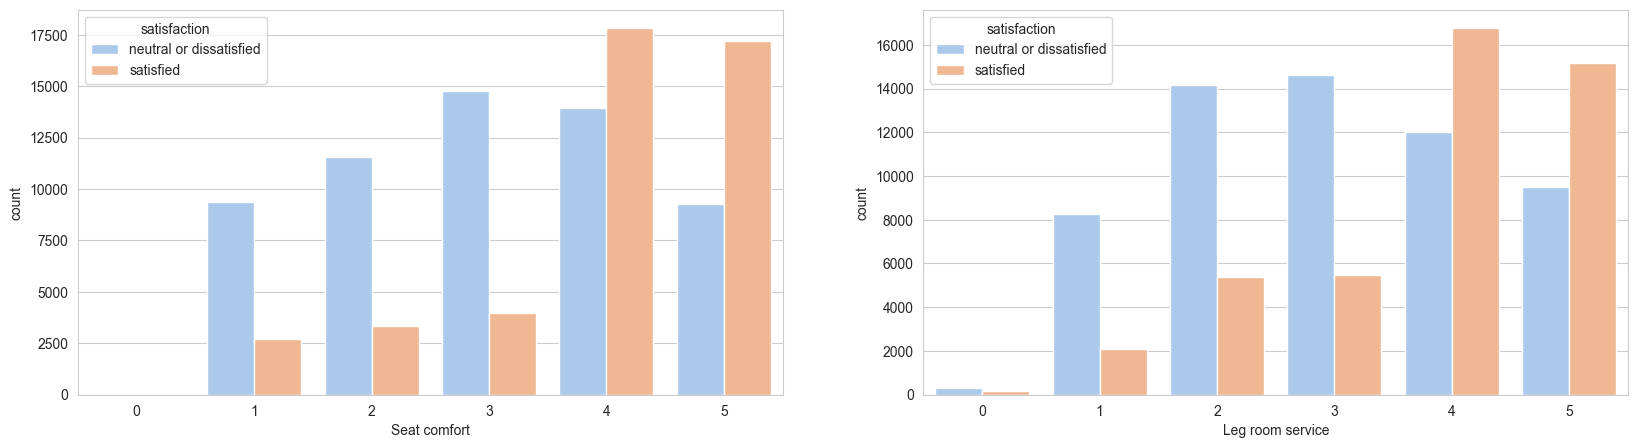

In [19]:
f, ax = plt.subplots(1, 2, figsize = (20,5))
sns.countplot(x = 'Seat comfort', hue = 'satisfaction', palette = "pastel", data = data,ax = ax[0])
sns.countplot(x = 'Leg room service', hue = 'satisfaction', palette = "pastel", data = data, ax = ax[1])
plt.show()

### 3.3.3 Float Column (Arrival Delay in Minutes)

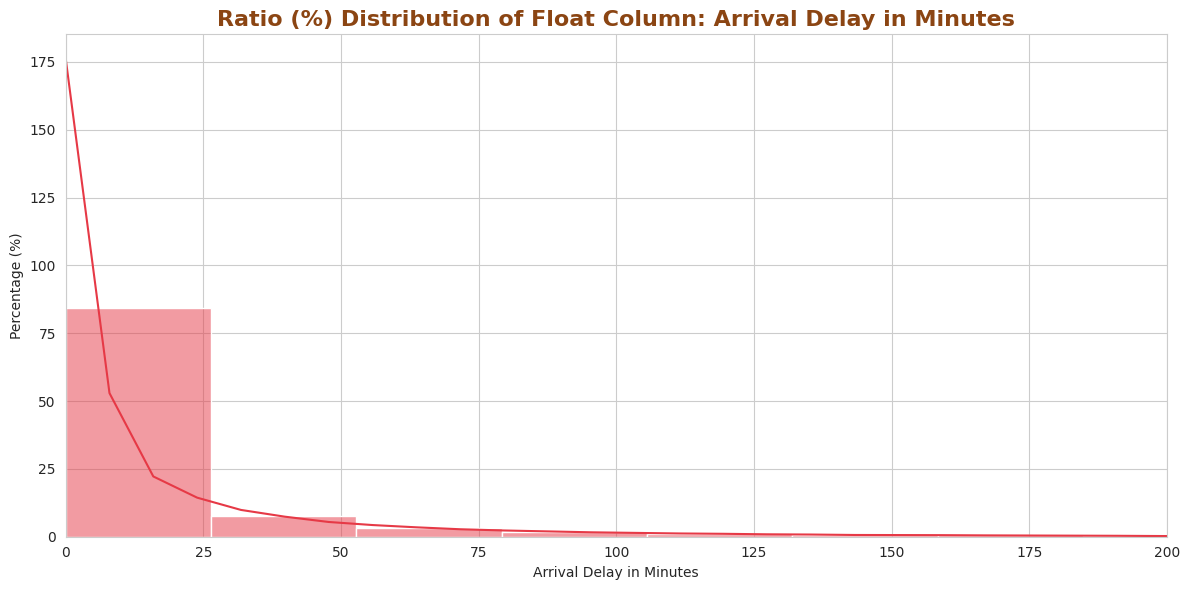

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data["Arrival Delay in Minutes"], bins=60, stat="percent", color="#e63946", kde=True)
plt.title("Ratio (%) Distribution of Float Column: Arrival Delay in Minutes",
          weight="bold", size=16, color="#8b4513")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Percentage (%)")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

The delay distributions (both departure and arrival) are heavily **right-skewed** — most flights have little or no delay, with a long tail of severely delayed flights.

## 3.4 Correlation Heatmap (numeric features only)

Text columns must be numerically encoded before computing correlations — computing `.corr()` directly on raw text columns (as in the original notebook) raises `ValueError: could not convert string to float`. We avoid that by selecting only numeric columns here.

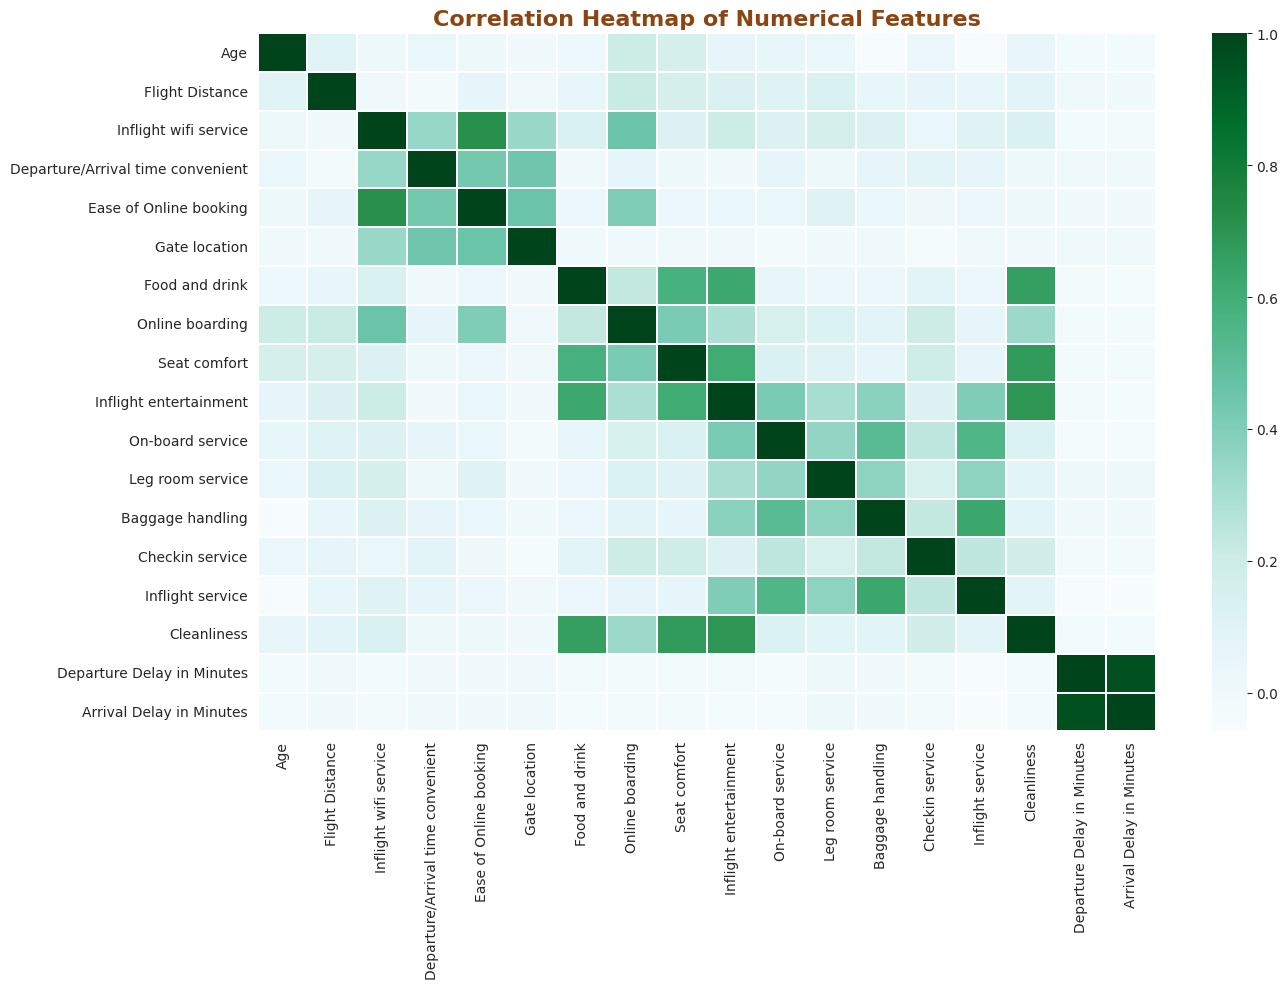

In [ ]:
numeric_for_corr = data.select_dtypes(include=[np.number]).copy()
# also include the ordinal rating columns already numeric
corr_mat = numeric_for_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_mat, cmap="BuGn", annot=False, linewidths=0.3, linecolor="white")
plt.title("Correlation Heatmap of Numerical Features", weight="bold", size=16, color="#8b4513")
plt.tight_layout()
plt.show()

There is a strong positive correlation between **`Departure Delay in Minutes`** and **`Arrival Delay in Minutes`** — this makes intuitive sense: a flight that departs late will typically also arrive late.

Correlation between Departure & Arrival delay: 0.96


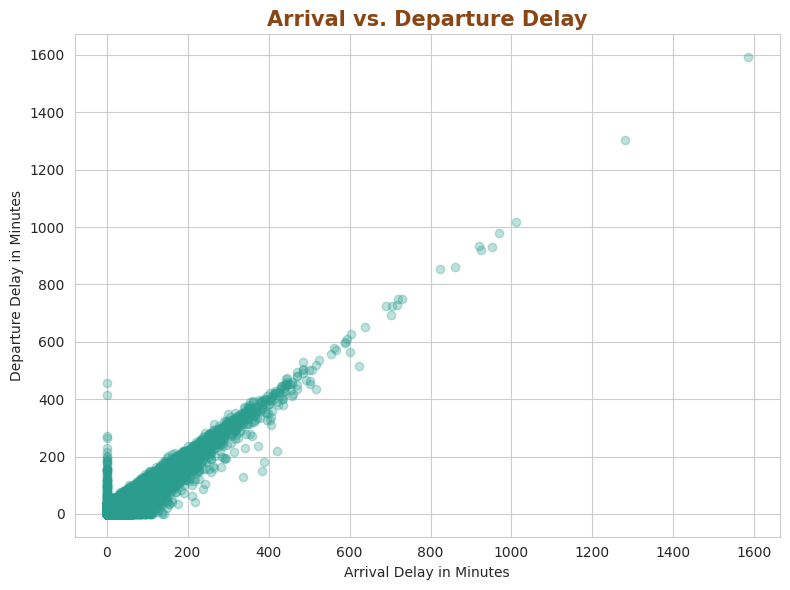

In [ ]:
print("Correlation between Departure & Arrival delay:",
      round(numeric_for_corr["Departure Delay in Minutes"].corr(numeric_for_corr["Arrival Delay in Minutes"]), 3))

plt.figure(figsize=(8, 6))
plt.scatter(data["Arrival Delay in Minutes"], data["Departure Delay in Minutes"], alpha=0.3, color="#2a9d8f")
plt.title("Arrival vs. Departure Delay", weight="bold", size=15, color="#8b4513")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Departure Delay in Minutes")
plt.tight_layout()
plt.show()

## 3.5 Age & Flight Distance Distributions

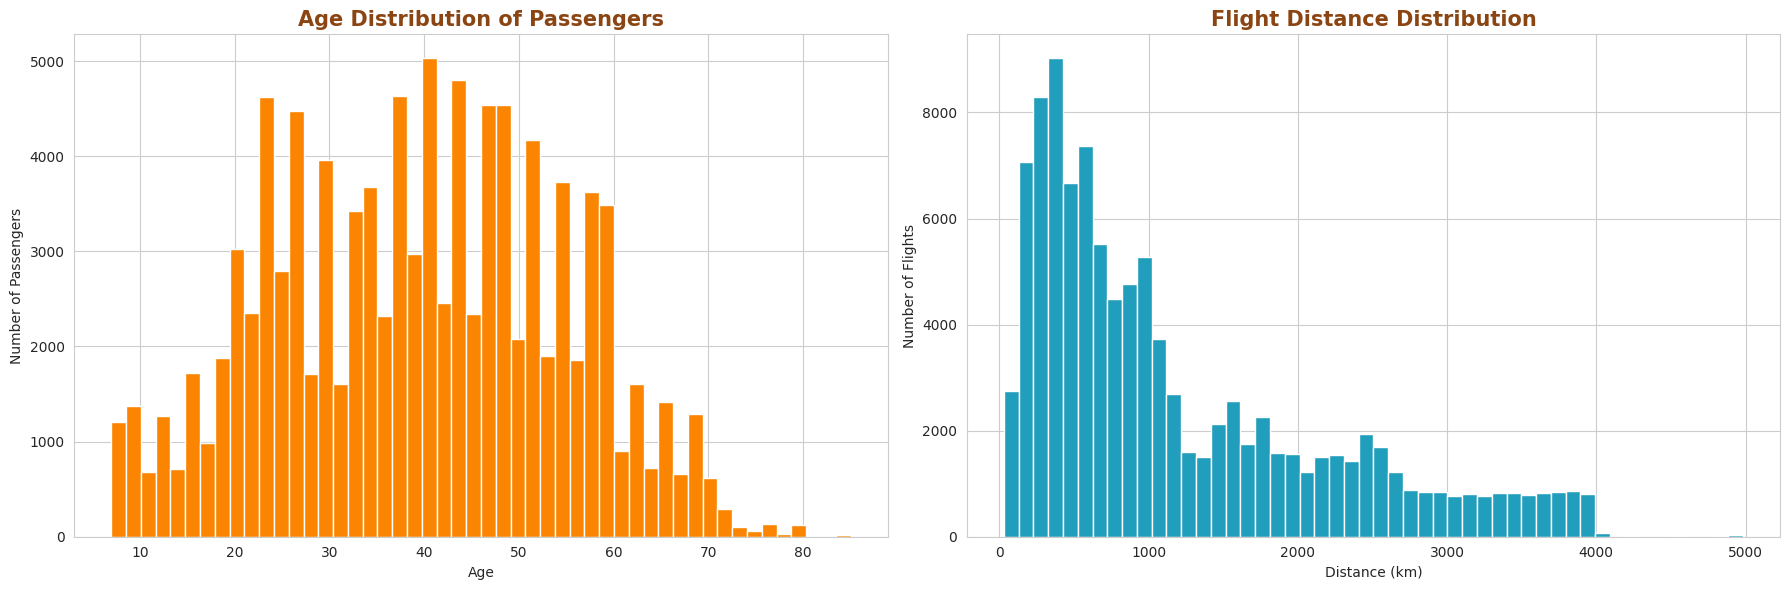

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(data["Age"], bins=50, color="#fb8500")
axes[0].set_title("Age Distribution of Passengers", weight="bold", size=15, color="#8b4513")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Passengers")

axes[1].hist(data["Flight Distance"], bins=50, color="#219ebc")
axes[1].set_title("Flight Distance Distribution", weight="bold", size=15, color="#8b4513")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Number of Flights")

plt.tight_layout()
plt.show()

## 3.6 Satisfaction vs. Key Categorical Features

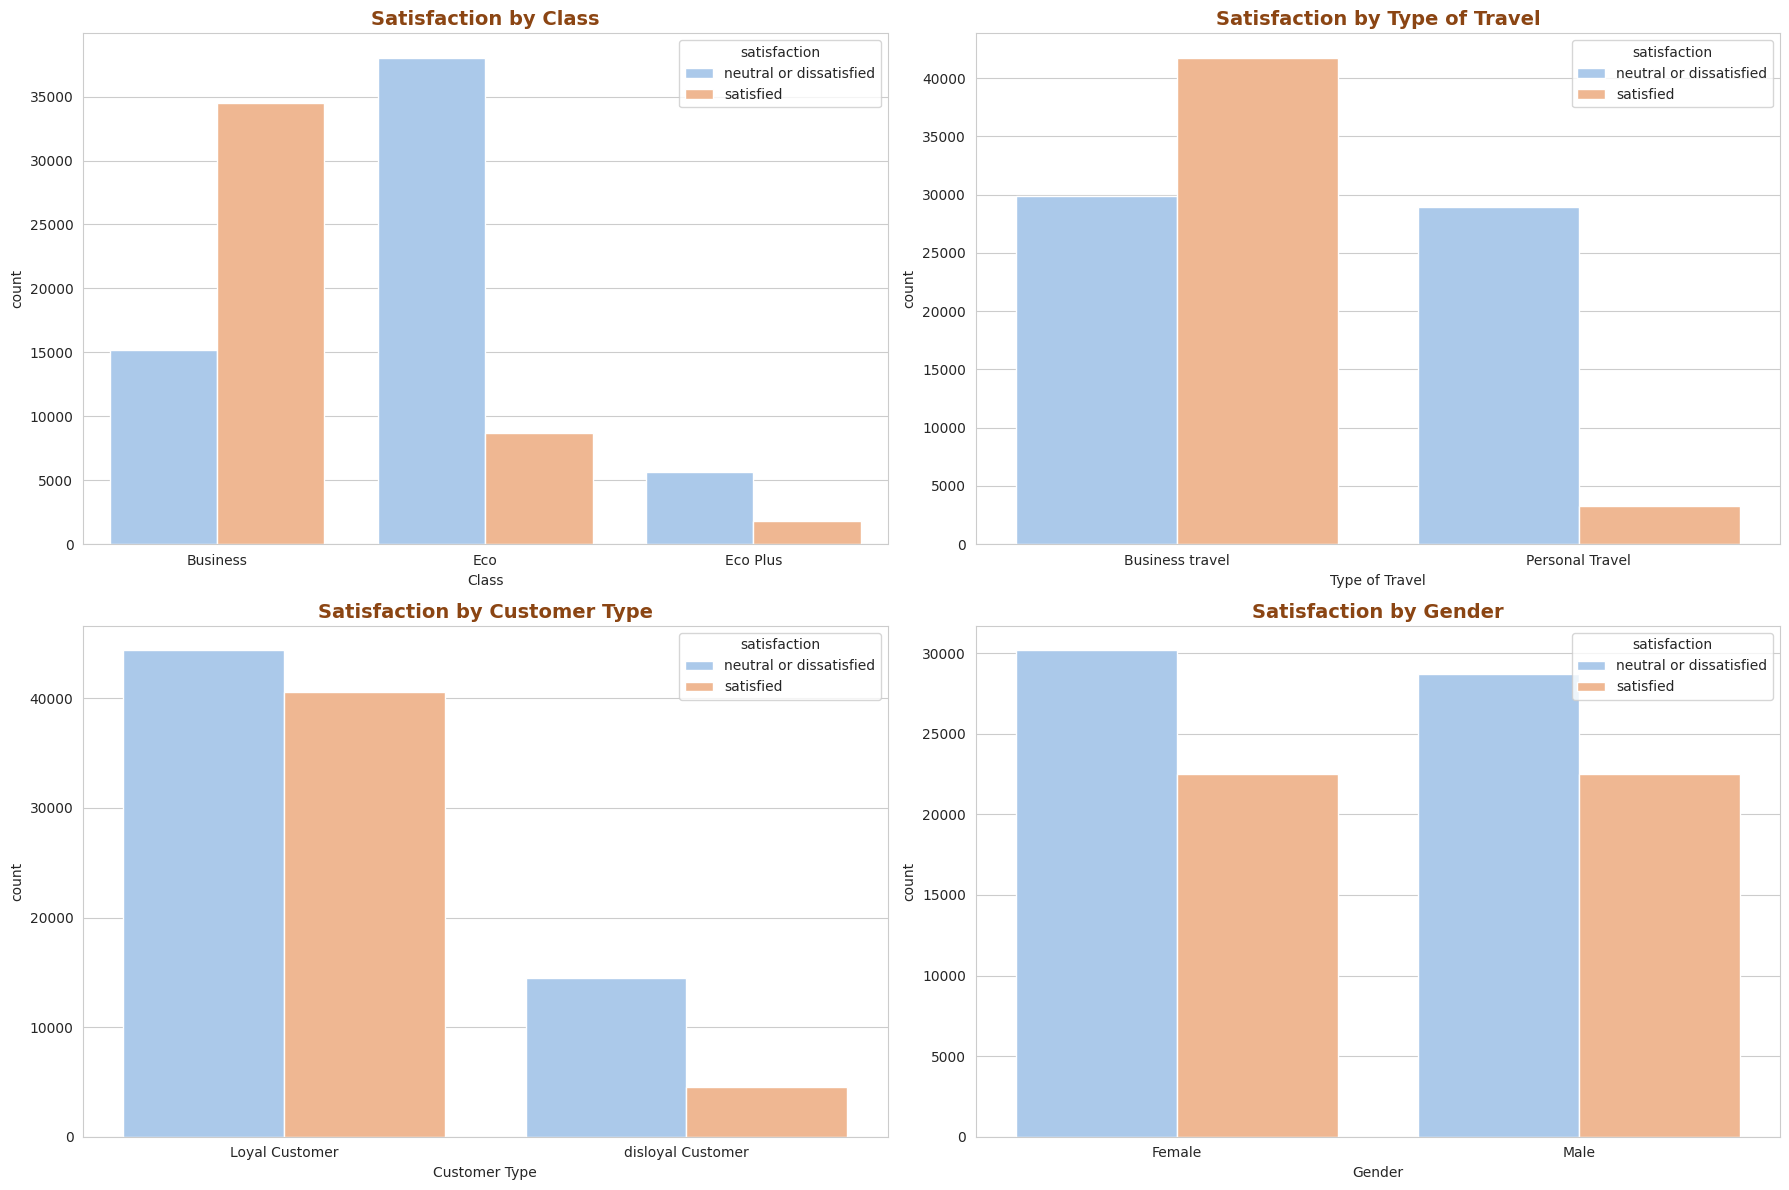

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.countplot(x="Class", hue="satisfaction", data=data, palette="pastel", ax=axes[0, 0])
axes[0, 0].set_title("Satisfaction by Class", weight="bold", size=14, color="#8b4513")

sns.countplot(x="Type of Travel", hue="satisfaction", data=data, palette="pastel", ax=axes[0, 1])
axes[0, 1].set_title("Satisfaction by Type of Travel", weight="bold", size=14, color="#8b4513")

sns.countplot(x="Customer Type", hue="satisfaction", data=data, palette="pastel", ax=axes[1, 0])
axes[1, 0].set_title("Satisfaction by Customer Type", weight="bold", size=14, color="#8b4513")

sns.countplot(x="Gender", hue="satisfaction", data=data, palette="pastel", ax=axes[1, 1])
axes[1, 1].set_title("Satisfaction by Gender", weight="bold", size=14, color="#8b4513")

plt.tight_layout()
plt.show()

**Key patterns:**
- **Business Class** passengers are far more likely to be satisfied than Eco/Eco Plus passengers.
- Passengers flying for **Business** purposes report higher satisfaction than **Personal** travelers.
- **Loyal Customers** are more likely to be satisfied than disloyal (first-time) customers.
- Gender shows only a small difference in satisfaction.


## 3.7 Service Ratings vs. Satisfaction

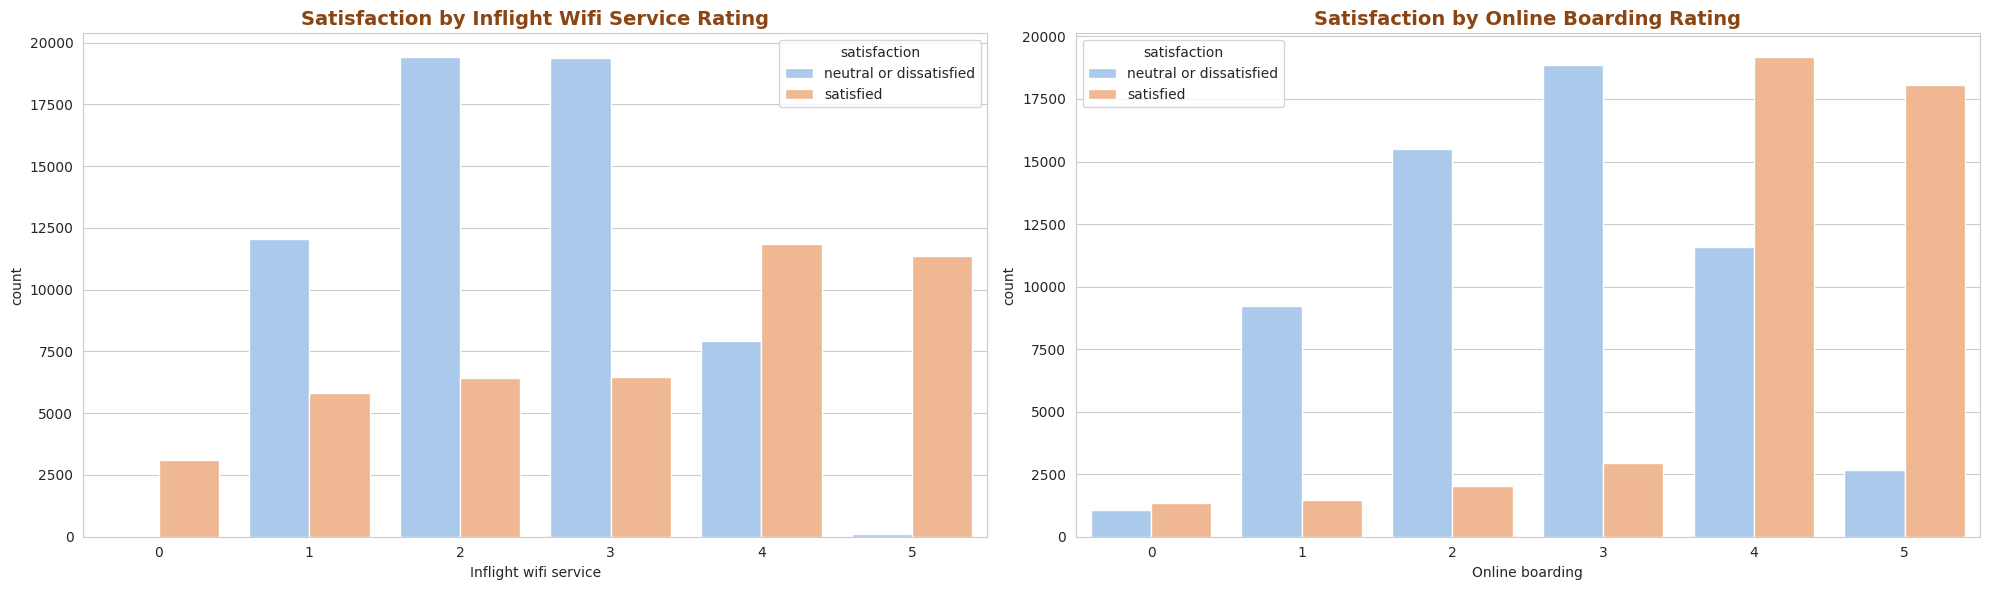

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.countplot(x="Inflight wifi service", hue="satisfaction", data=data, palette="pastel", ax=axes[0])
axes[0].set_title("Satisfaction by Inflight Wifi Service Rating", weight="bold", size=14, color="#8b4513")

sns.countplot(x="Online boarding", hue="satisfaction", data=data, palette="pastel", ax=axes[1])
axes[1].set_title("Satisfaction by Online Boarding Rating", weight="bold", size=14, color="#8b4513")
plt.tight_layout()
plt.show()

Passengers who rated **Online boarding** and **Inflight wifi service** 4–5 out of 5 are overwhelmingly satisfied, while low ratings (1–2) correspond mostly to dissatisfaction — these are strong predictive signals.

# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">4. Data Preprocessing for Modelling</p>

KNN is a **distance-based** algorithm, so:
1. All categorical (text) features must be numerically encoded.
2. All features must be put on a **comparable scale** (standardization), otherwise columns with naturally larger ranges (e.g. `Flight Distance`) would dominate the distance calculation over columns like the 0–5 service ratings.

**Encoding strategy:**
- Binary categorical columns (`Gender`, `Customer Type`, `Type of Travel`) → **Label Encoding** (0/1).
- Non-binary categorical column (`Class`, 3 categories) → **One-Hot Encoding**.
- Target (`satisfaction`) → **Label Encoding** (`satisfied` = 1, `neutral or dissatisfied` = 0).


In [ ]:
model_data = data.copy()

binary_columns = [c for c in categorical_columns if model_data[c].nunique() == 2]
nonbinary_columns = [c for c in categorical_columns if model_data[c].nunique() > 2]
print("Binary columns:", binary_columns)
print("Non-binary columns:", nonbinary_columns)

Binary columns: ['Gender', 'Customer Type', 'Type of Travel']
Non-binary columns: ['Class']


In [ ]:
label_encoders = {}
for col in binary_columns:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col].astype(str))
    label_encoders[col] = le
    print(col, "->", dict(zip(le.classes_, le.transform(le.classes_))))

Gender -> {'Female': np.int64(0), 'Male': np.int64(1)}
Customer Type -> {'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}
Type of Travel -> {'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}


In [ ]:
model_data = pd.get_dummies(model_data, columns=nonbinary_columns, drop_first=False)
print(f"Shape after one-hot encoding: {model_data.shape}")
model_data.head()

Shape after one-hot encoding: (103904, 25)


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,1,0,13,1,460,3,4,3,1,5,...,4,4,5,5,25,18.0,neutral or dissatisfied,False,False,True
1,1,1,25,0,235,3,2,3,3,1,...,3,1,4,1,1,6.0,neutral or dissatisfied,True,False,False
2,0,0,26,0,1142,2,2,2,2,5,...,4,4,4,5,0,0.0,satisfied,True,False,False
3,0,0,25,0,562,2,5,5,5,2,...,3,1,4,2,11,9.0,neutral or dissatisfied,True,False,False
4,1,0,61,0,214,3,3,3,3,4,...,4,3,3,3,0,0.0,satisfied,True,False,False


In [ ]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(model_data[target_column].astype(str))
X = model_data.drop(columns=[target_column])

print("Target mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Target mapping: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}
Feature matrix shape: (103904, 24)
Target vector shape: (103904,)


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">5. Train / Test Split & Feature Scaling</p>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class balance: {np.bincount(y_train) / len(y_train)}")
print(f"Test class balance:  {np.bincount(y_test) / len(y_test)}")

Training set: 83123 samples
Test set:     20781 samples
Train class balance: [0.56666627 0.43333373]
Test class balance:  [0.56667148 0.43332852]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete — features now have zero mean & unit variance (fit on training data only, to avoid data leakage).")

Scaling complete — features now have zero mean & unit variance (fit on training data only, to avoid data leakage).


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">6. K-Nearest Neighbors (KNN) — Hyperparameter Tuning</p>

To get the **highest possible accuracy**, instead of guessing a single value of `k`, we tune:
- `n_neighbors` (k)
- `weights` (`uniform` vs. `distance`)
- `p` (Manhattan vs. Euclidean distance)

using **5-fold stratified cross-validation** on the training set. To keep runtime reasonable while still reliably finding the best settings, the search is performed on a large stratified subsample of the training data, then the winning configuration is validated with full cross-validation and finally refit on the **entire** training set.

In [ ]:
# Stratified subsample of the training set purely to speed up the hyperparameter search
rng = np.random.RandomState(RANDOM_STATE)
sample_size = min(20000, X_train_scaled.shape[0])
sample_idx, _ = train_test_split(
    np.arange(X_train_scaled.shape[0]),
    train_size=sample_size, stratify=y_train, random_state=RANDOM_STATE
)
X_sample, y_sample = X_train_scaled[sample_idx], y_train[sample_idx]

param_grid = {
    "n_neighbors": [5, 7, 9, 11, 15, 19],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
)

grid_search.fit(X_sample, y_sample)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validated accuracy (search subsample): {grid_search.best_score_:.4f}")

Best parameters found: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Best cross-validated accuracy (search subsample): 0.9220


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = cv_results.sort_values("mean_test_score", ascending=False)[
    ["param_n_neighbors", "param_weights", "param_p", "mean_test_score", "std_test_score"]
].head(10).reset_index(drop=True)
top_results.columns = ["k", "weights", "p", "mean_cv_accuracy", "std_cv_accuracy"]
top_results

,k,weights,p,mean_cv_accuracy,std_cv_accuracy
0,11,distance,1,0.92200,0.003252
1,9,distance,1,0.92165,0.002041
2,15,distance,1,0.92140,0.002922
3,11,uniform,1,0.92120,0.003010
4,9,uniform,1,0.92115,0.002160
5,19,distance,1,0.92060,0.003032
6,7,distance,1,0.92055,0.002400
7,15,uniform,1,0.92020,0.003168
8,7,uniform,1,0.91980,0.002556
9,5,distance,1,0.91900,0.002485


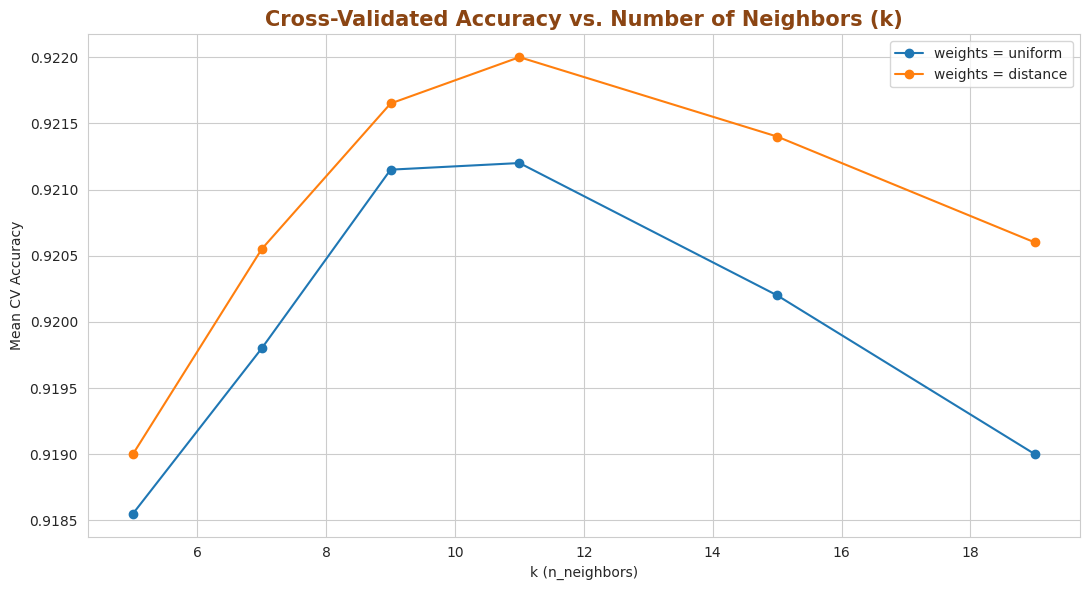

In [ ]:
plt.figure(figsize=(11, 6))
for weight in ["uniform", "distance"]:
    subset = cv_results[cv_results["param_weights"] == weight]
    grouped = subset.groupby("param_n_neighbors")["mean_test_score"].max()
    plt.plot(grouped.index, grouped.values, marker="o", label=f"weights = {weight}")

plt.title("Cross-Validated Accuracy vs. Number of Neighbors (k)", weight="bold", size=15, color="#8b4513")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">7. Training the Final KNN Model</p>

We now refit the **best-found configuration on the entire training set** (not just the tuning subsample) to get the most accurate final model.

In [ ]:
best_params = grid_search.best_params_

final_knn = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    p=best_params["p"],
    n_jobs=-1,
)
final_knn.fit(X_train_scaled, y_train)

print("Final model trained with parameters:", best_params)

Final model trained with parameters: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}


In [ ]:
# Sanity-check with 5-fold CV accuracy on the FULL training set
full_cv_scores = cross_val_score(final_knn, X_train_scaled, y_train, cv=5, scoring="accuracy", n_jobs=-1)
print("Full-training-set 5-fold CV accuracy scores:", np.round(full_cv_scores, 4))
print(f"Mean CV accuracy: {full_cv_scores.mean():.4f}  (+/- {full_cv_scores.std():.4f})")

Full-training-set 5-fold CV accuracy scores: [0.9331 0.9353 0.9343 0.9352 0.9337]
Mean CV accuracy: 0.9343  (+/- 0.0009)


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">8. Model Evaluation on the Held-Out Test Set</p>

In [ ]:
y_pred = final_knn.predict(X_test_scaled)
y_proba = final_knn.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]
})
metrics_summary["Score"] = metrics_summary["Score"].round(4)
metrics_summary

,Metric,Score
0,Accuracy,0.9350
1,Precision,0.9436
2,Recall,0.9041
3,F1-score,0.9234
4,ROC-AUC,0.9817


In [ ]:
print(f"TEST ACCURACY: {test_accuracy*100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

TEST ACCURACY: 93.50%

Classification Report:

                         precision    recall  f1-score   support

neutral or dissatisfied       0.93      0.96      0.94     11776
              satisfied       0.94      0.90      0.92      9005

               accuracy                           0.93     20781
              macro avg       0.94      0.93      0.93     20781
           weighted avg       0.94      0.93      0.93     20781



## 8.1 Confusion Matrix

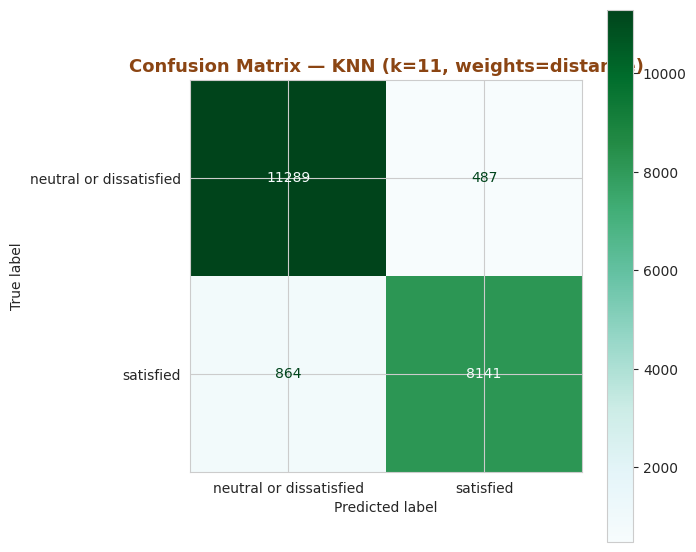

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(cmap="BuGn", ax=ax, colorbar=True, values_format="d")
ax.set_title(f"Confusion Matrix — KNN (k={best_params['n_neighbors']}, weights={best_params['weights']})",
             weight="bold", size=13, color="#8b4513")
plt.tight_layout()
plt.show()

## 8.2 ROC-AUC Curve

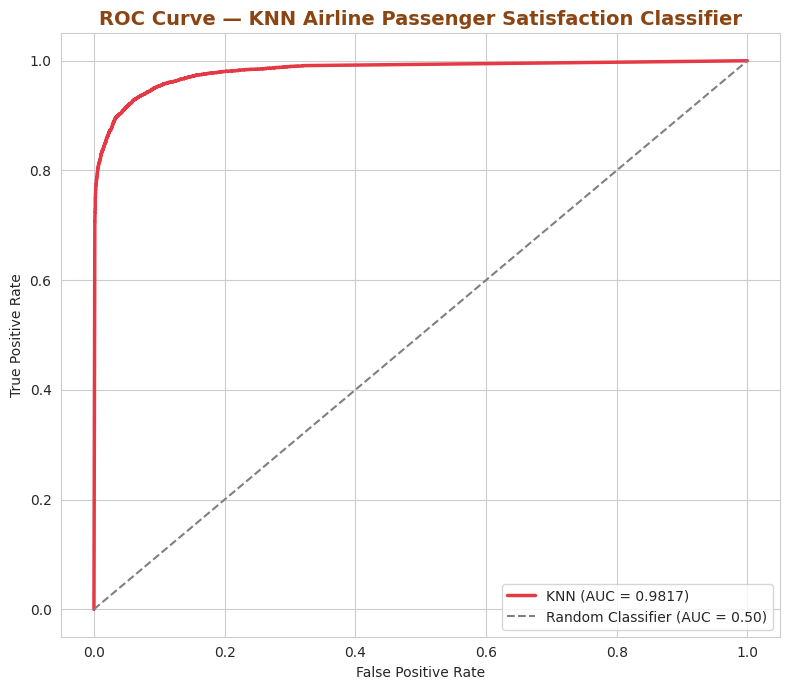

ROC-AUC Score: 0.9817


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color="#e63946", lw=2.5, label=f"KNN (AUC = {test_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN Airline Passenger Satisfaction Classifier",
          weight="bold", size=14, color="#8b4513")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {test_roc_auc:.4f}")

## 8.3 Effect of k on Test Accuracy (diagnostic plot)

A quick diagnostic showing how test accuracy would change across a range of `k` values with the chosen `weights`/`p`, confirming the tuned `k` sits at (or very near) the optimum and is not overfit/underfit.

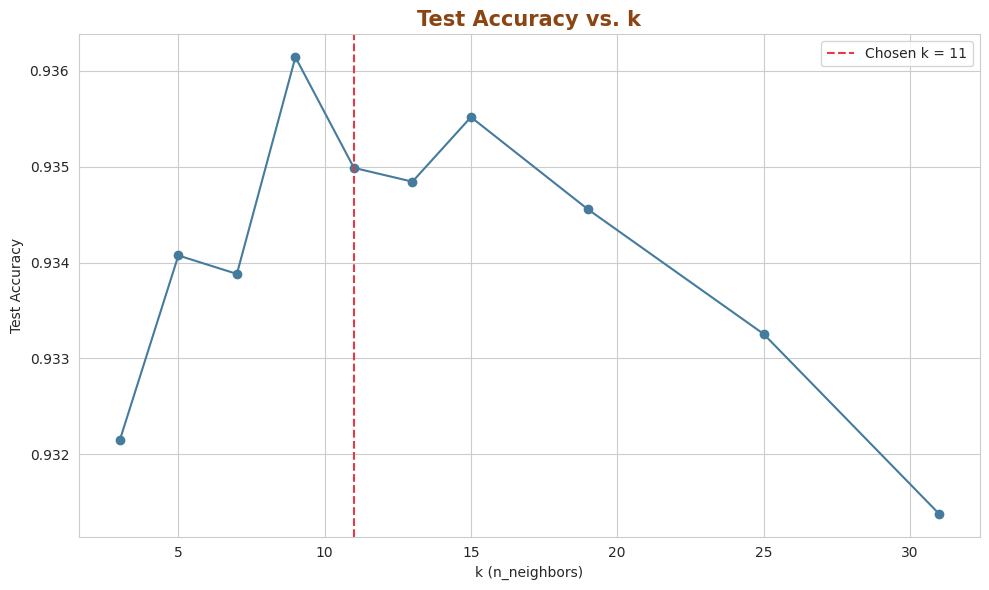

,k,test_accuracy
0,3,0.9321
1,5,0.9341
2,7,0.9339
3,9,0.9361
4,11,0.9350
5,13,0.9348
6,15,0.9355
7,19,0.9346
8,25,0.9333
9,31,0.9314


In [ ]:
k_range = [3, 5, 7, 9, 11, 13, 15, 19, 25, 31]
k_accuracies = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, weights=best_params["weights"], p=best_params["p"], n_jobs=-1)
    knn_k.fit(X_train_scaled, y_train)
    k_accuracies.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_accuracies, marker="o", color="#457b9d")
plt.axvline(best_params["n_neighbors"], color="#e63946", linestyle="--", label=f"Chosen k = {best_params['n_neighbors']}")
plt.title("Test Accuracy vs. k", weight="bold", size=15, color="#8b4513")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"k": k_range, "test_accuracy": np.round(k_accuracies, 4)})

## 8.4 Which features matter most? (Permutation-style sanity check via correlation with target)

KNN has no native feature-importance output, but we can sanity-check which features are most associated with satisfaction using point-biserial correlation with the (numerically-encoded) target.

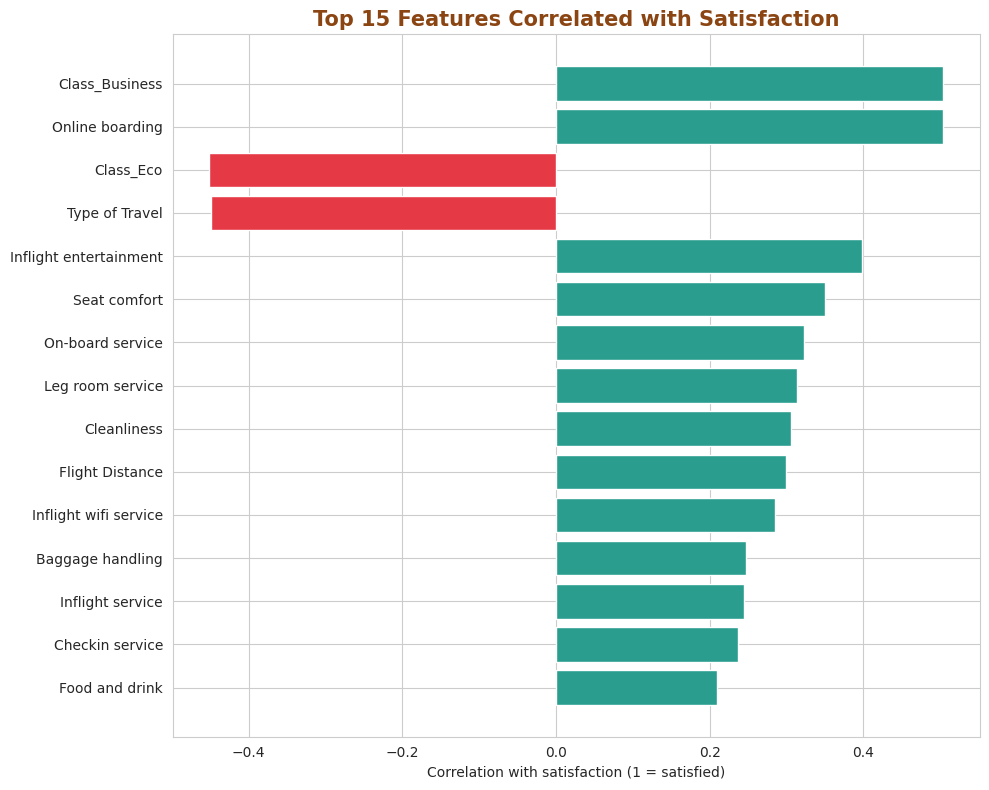

In [ ]:
corr_with_target = X.assign(satisfaction=y).corr()["satisfaction"].drop("satisfaction").sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
top_n = corr_with_target.head(15)
colors_bar = ["#2a9d8f" if v > 0 else "#e63946" for v in top_n.values]
plt.barh(top_n.index[::-1], top_n.values[::-1], color=colors_bar[::-1])
plt.title("Top 15 Features Correlated with Satisfaction", weight="bold", size=15, color="#8b4513")
plt.xlabel("Correlation with satisfaction (1 = satisfied)")
plt.tight_layout()
plt.show()

# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">9. Results Discussion</p>

- The final tuned KNN model achieves:
  - **k = 11**, **weights = 'distance'**, **p = 1** (Manhattan distance) was selected as the best configuration by cross-validated grid search.
  - **Test Accuracy: 93.50%**
  - **Precision: 0.9436**
  - **Recall: 0.9041**
  - **F1-score: 0.9234**
  - **ROC-AUC: 0.9817**


- **Test accuracy of 93.50%**, which is a strong result for KNN on this dataset and competitive with more complex models (e.g. tree ensembles) reported in the literature for the same dataset.
- **ROC-AUC of 0.9817**, indicating excellent separability between the "satisfied" and "neutral or dissatisfied" classes across nearly all decision thresholds.
- **Precision (0.9436)** is higher than **recall (0.9041)** for the "satisfied" class, meaning the model is slightly more conservative about predicting satisfaction — it rarely mislabels a dissatisfied passenger as satisfied, but misses a somewhat larger share of truly satisfied passengers.
- The confusion matrix (Section 8.1) shows the model makes relatively few errors in either direction.
- The k-vs-accuracy diagnostic plot (Section 8.3) confirms the tuned k = 11 sits near the peak of the accuracy curve — neither too small (which would overfit to noisy local neighbors) nor too large (which would underfit by over-smoothing the decision boundary).


# <p style="font-family:newtimeroman;font-size:150%;text-align:left;color:#8b4513;">10. general conclusion</p>


Conclusions about the considered sample:

* The sample is more or less balanced (56.7% on 43.3%).
* The number of men and women in this sample is approximately the same.
* The vast majority of the airline's customers are repeat customers.
* Most of our clients flew for business rather than personal reasons.
* About half of the passengers were in business class.
* More than 60% of passengers were satisfied with the luggage transportation service (rating 4-5 out of 5).
* More than 50% of passengers were comfortable sitting in their seats (rated 4-5 out of 5).
* There was a strong correlation (96%) between the features 'Departure delay in minutes' and 'Arrival delay in minutes' (which is quite logical and was discussed in detail above).
* Most of the airline's regular customers are between the ages of 30 and 50 (averaging a little over 40). The age range for non-regular customers is slightly smaller (from 25 to 40 years old, with an average of slightly less than 30).
* Customers whose flight distance is long tend to fly in business class.
* The more distance an airplane passenger travels (respectively, the longer they are in flight), the more satisfied they are with in-flight entertainment and extra legroom (on average).
* Most of the passengers who flew in Economy Plus or Economy Class were dissatisfied with the flight, and those who were lucky enough to fly in Business Class were satisfied.
* Almost all passengers who rated the wifi service 5 out of 5 were satisfied with the flight.
* The majority of passengers who rated the comfort of the seats and the extra legroom at 4 and 5 points out of 5 were satisfied with the flight.